#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
!pip install phik

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import warnings

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [2]:
try:
    taxi = pd.read_csv('/datasets/taxi.csv', decimal=',')
except: 
    taxi = pd.read_csv('C:\\Users\\andre\\Downloads\\taxi.csv', decimal=',')

In [3]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


In [4]:
taxi.head()

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


Датасет содержит временной ряд с кол-вом заказов и интервалом 10 минут

## Предобработка данных

In [5]:
taxi.isna().sum()

datetime      0
num_orders    0
dtype: int64

In [6]:
taxi.index.duplicated().sum()

0

In [7]:
taxi.sort_index(inplace=True)
taxi.index.is_monotonic_increasing

True

In [8]:
taxi['datetime'] = pd.to_datetime(taxi['datetime'])
taxi.set_index('datetime', inplace=True)


In [9]:
taxi_1h = taxi.resample('1h').sum()
taxi_1h.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


Пропуски и дубликаты не обнаружены,ресемплируем временной ряд (интервалы в 1 час)

## Анализ

In [10]:
taxi_1h.index.to_frame().describe().T

/tmp/ipykernel_47/1645227970.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  taxi_1h.index.to_frame().describe().T


,count,unique,top,freq,first,last
datetime,4416,4416,2018-04-24 20:00:00,1,2018-03-01,2018-08-31 23:00:00


Промежуток данных с 1 марта 2018 года по 31 августа 2018 года

In [11]:
taxi_1h.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,4416.0,84.422781,45.023853,0.0,54.0,78.0,107.0,462.0


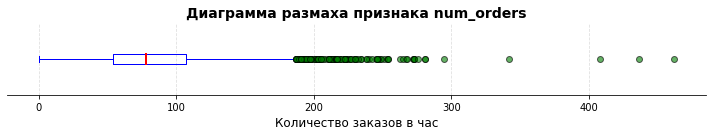

In [12]:
fig, ax = plt.subplots(figsize=(10, 2))

taxi_1h['num_orders'].plot.box(
    vert=False,
    ax=ax,
    medianprops={'color': 'red', 'linewidth': 2},
    boxprops={'color': 'blue'},
    whiskerprops={'color': 'blue'},
    capprops={'color': 'blue'},
    flierprops={'marker': 'o', 'markerfacecolor': 'green', 'alpha': 0.6}
)

ax.set_title('Диаграмма размаха признака num_orders', fontsize=14, weight='bold')
ax.set_xlabel('Количество заказов в час', fontsize=12)
ax.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='x', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()


Имеется небольшое количество выбросов.

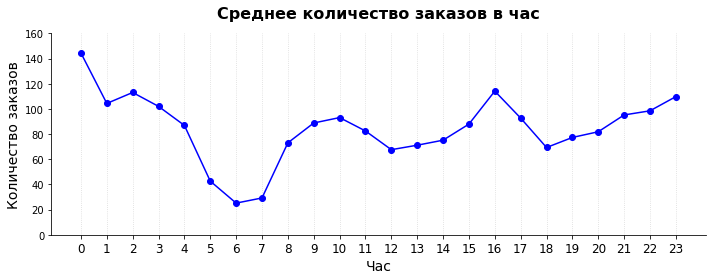

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

taxi_1h.groupby(taxi_1h.index.hour)['num_orders'].mean().plot(ax=ax, color='blue', marker='o', linestyle='-')

ax.set_title('Среднее количество заказов в час', fontsize=16, weight='bold', pad=15)

ax.set_xlabel('Час', fontsize=14)
ax.set_ylabel('Количество заказов', fontsize=14)

ax.set_xticks(range(24))
ax.tick_params(axis='x', labelsize=12)

ax.set_ylim(0, 160)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', alpha=0.5, linestyle=':')

plt.tight_layout()
plt.show()


Количество заказов понижается в ранние часы.

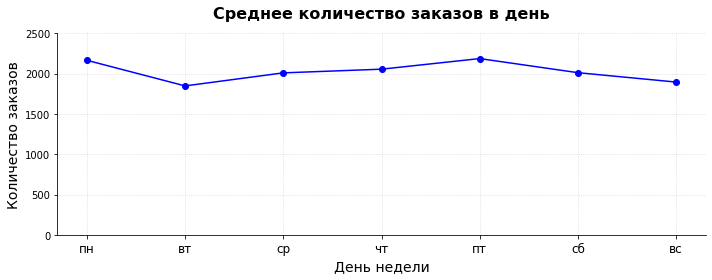

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

taxi_1d = taxi_1h.resample('1D').sum()
mean_orders_by_day = taxi_1d.groupby(taxi_1d.index.dayofweek)['num_orders'].mean()

mean_orders_by_day.plot(ax=ax, marker='o', linestyle='-', color='blue')

ax.set_title('Среднее количество заказов в день', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('День недели', fontsize=14)
ax.set_ylabel('Количество заказов', fontsize=14)

days_labels = ['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс']
ax.set_xticks(range(7))
ax.set_xticklabels(days_labels, fontsize=12)

ax.set_ylim(0, 2500)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(alpha=0.5, linestyle=':')

plt.tight_layout()
plt.show()


Больше всего заказов в понедельник и пятницу.

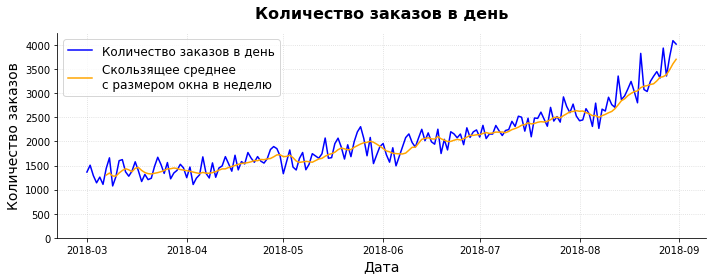

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

taxi_1d = taxi_1h.resample('1D').sum()
taxi_1d['rolling_mean'] = taxi_1d['num_orders'].rolling(7).mean()

ax.plot(taxi_1d.index, taxi_1d['num_orders'], label='Количество заказов в день', color='blue')
ax.plot(taxi_1d.index, taxi_1d['rolling_mean'], label='Скользящее среднее\nс размером окна в неделю', color='orange')

ax.set_title('Количество заказов в день', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Количество заказов', fontsize=14)
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle=':')

ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


Виден постепенный рост заказов

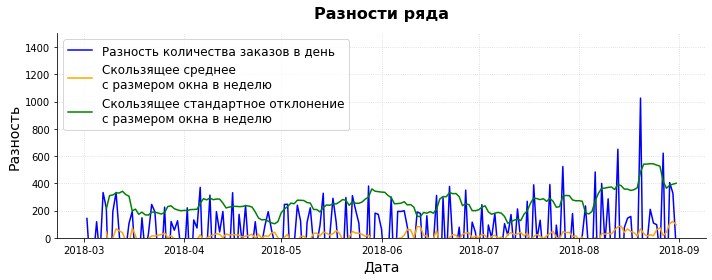

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

diff_df = (taxi_1d - taxi_1d.shift()).assign(
    mean_1w=lambda x: x['num_orders'].rolling(7).mean(),
    std_1w=lambda x: x['num_orders'].rolling(7).std()
)

ax.plot(diff_df.index, diff_df['num_orders'], label='Разность количества заказов в день', color='blue')
ax.plot(diff_df.index, diff_df['mean_1w'], label='Скользящее среднее\nс размером окна в неделю', color='orange')
ax.plot(diff_df.index, diff_df['std_1w'], label='Скользящее стандартное отклонение\nс размером окна в неделю', color='green')

ax.set_title('Разности ряда', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Разность', fontsize=14)
ax.set_ylim(top=1500, bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle=':')

ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


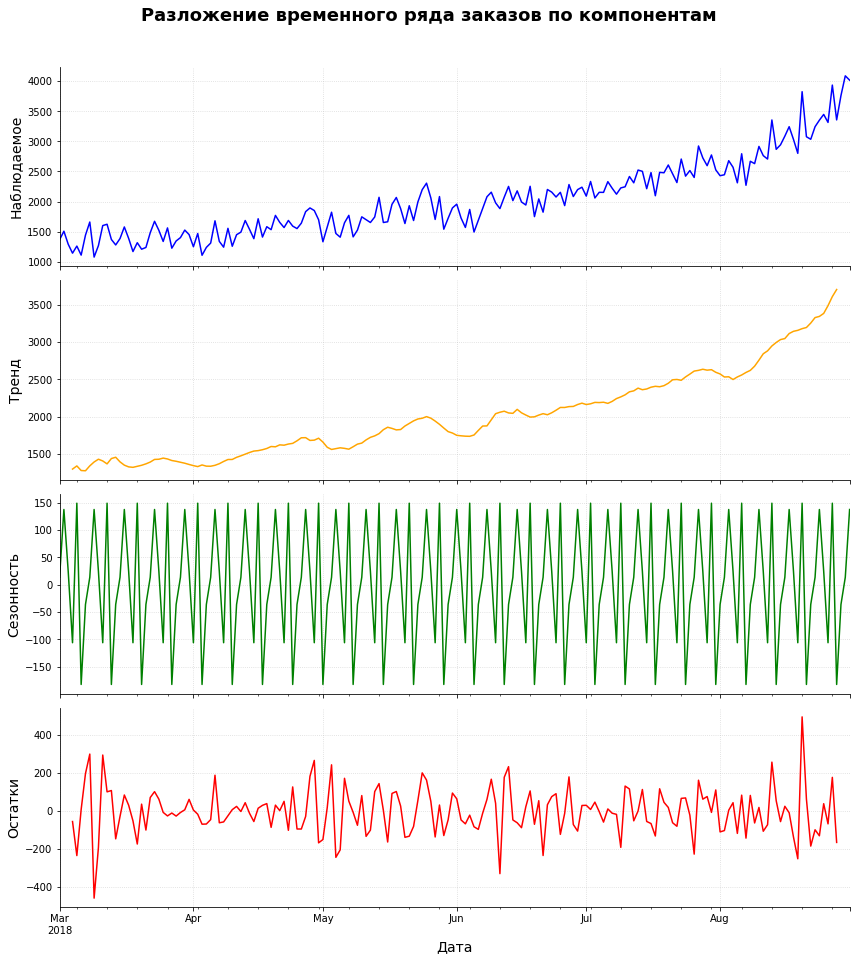

In [17]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

decomposed_taxi_1d = seasonal_decompose(taxi_1d['num_orders'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
fig.suptitle('Разложение временного ряда заказов по компонентам', fontsize=18, weight='bold', y=0.95)

decomposed_taxi_1d.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Наблюдаемое', fontsize=14)
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

decomposed_taxi_1d.trend.plot(ax=axes[1], color='orange', legend=False)
axes[1].set_ylabel('Тренд', fontsize=14)
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

decomposed_taxi_1d.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Сезонность', fontsize=14)
axes[2].grid(True, linestyle=':', alpha=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

decomposed_taxi_1d.resid.plot(ax=axes[3], color='red', legend=False)
axes[3].set_ylabel('Остатки', fontsize=14)
axes[3].set_xlabel('Дата', fontsize=14)
axes[3].grid(True, linestyle=':', alpha=0.5)
axes[3].spines['top'].set_visible(False)
axes[3].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


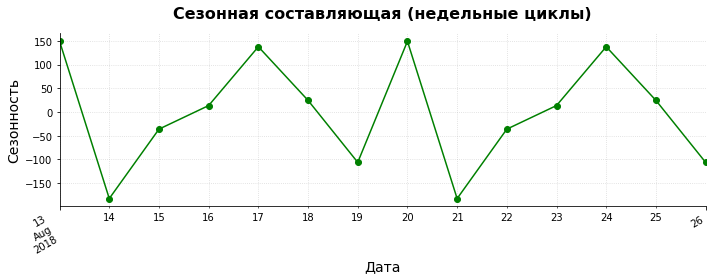

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

seasonal_segment = decomposed_taxi_1d.seasonal['2018-08-13':'2018-08-26']

seasonal_segment.plot(ax=ax, color='green', marker='o', linestyle='-')

ax.set_title('Сезонная составляющая (недельные циклы)', fontsize=16, weight='bold', pad=15)

ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Сезонность', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='both', which='both', alpha=0.5, linestyle=':')

fig.autofmt_xdate()

plt.tight_layout()
plt.show()


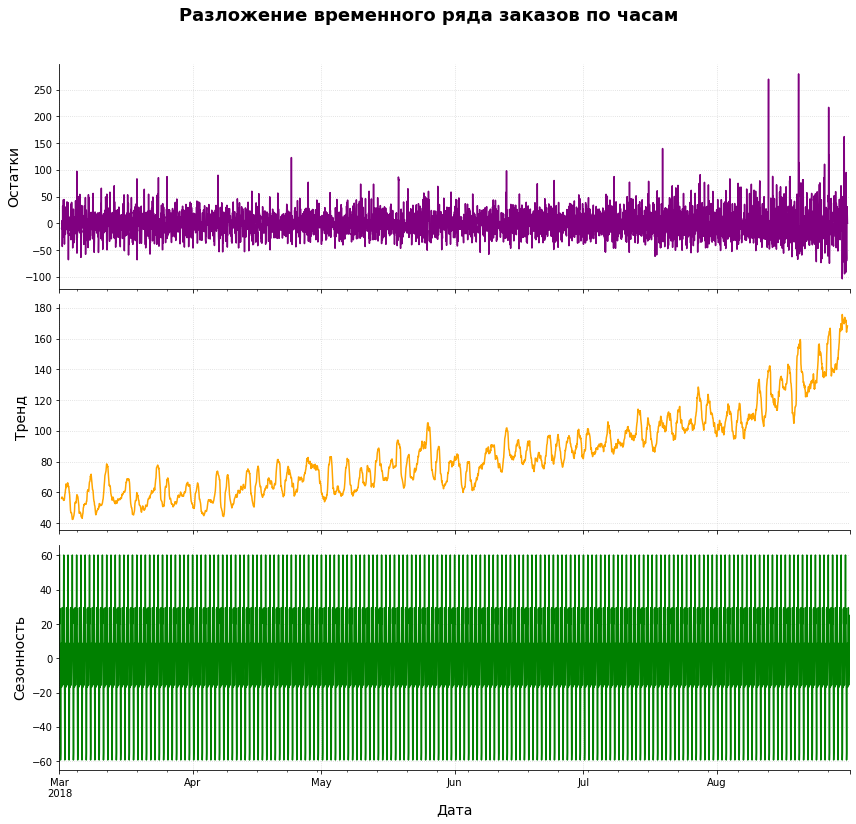

In [19]:
decomposed_taxi_1h = seasonal_decompose(taxi_1h['num_orders'], model='additive', period=24)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle('Разложение временного ряда заказов по часам', fontsize=18, weight='bold', y=0.95)

decomposed_taxi_1h.resid.plot(ax=axes[0], color='purple', legend=False)
axes[0].set_ylabel('Остатки', fontsize=14)
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

decomposed_taxi_1h.trend.plot(ax=axes[1], color='orange', legend=False)
axes[1].set_ylabel('Тренд', fontsize=14)
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

decomposed_taxi_1h.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Сезонность', fontsize=14)
axes[2].set_xlabel('Дата', fontsize=14)
axes[2].grid(True, linestyle=':', alpha=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



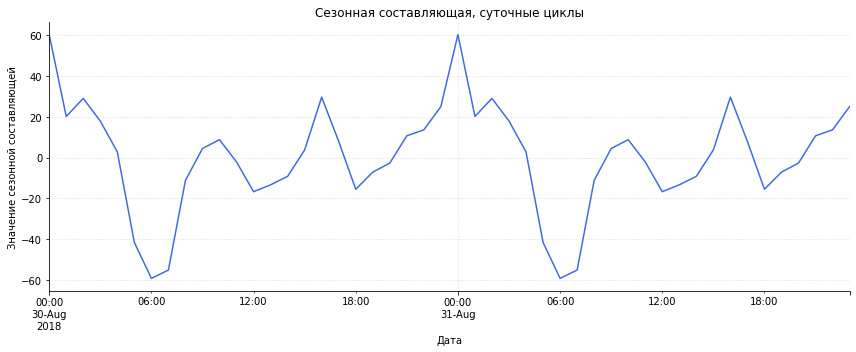

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

decomposed_taxi_1h.seasonal['2018-08-30':'2018-08-31'].plot(ax=ax, color='royalblue', linestyle='-')
ax.set_title('Сезонная составляющая, суточные циклы')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение сезонной составляющей')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='both', linestyle=':', linewidth=0.7, alpha=0.6)

fig.tight_layout()
plt.show()


Выделение трендовых и сезонных компонентов временного ряда позволило выявить закономерности в заказах такси: обнаружилась цикличность с периодами в сутки и неделю, а также устойчивый рост количества заказов с начала весны до конца лета 2018 года. Максимальное число заказов приходится на полночь, уменьшаясь до минимальных значений около 6 утра. Кроме того, пик активности наблюдается по понедельникам и пятницам. Вместе с тем отмечается существенный шум, не объясняющийся ни трендом, ни сезонностью, который может быть вызван разнообразными внешними факторами — погодными условиями, крупными культурными и спортивными мероприятиями, дорожными пробками и другими обстоятельствами. Этот шум отражает сложность и многогранность факторов, влияющих на количество заказов в такси.

Добавление новых признаков для прогнозирования(отстат знач,календарные признаки и значения с отставанием)

In [21]:
def add_feature(df, lag_list, rolling_size):
    df_copy = df.copy()
    
    df_copy['dayofweek'] = df_copy.index.dayofweek

    df_copy['rolling_mean'] = df_copy['num_orders'].shift().rolling(rolling_size).mean()

    for lag in lag_list:
        df_copy[f'num_orders_lag_{lag}'] = df_copy['num_orders'].shift(lag)

    return df_copy

taxi_1h_new = add_feature(taxi_1h, [1, 2, 24, 24 * 2, 24 * 7], 24)
taxi_1h_new.head()

,num_orders,dayofweek,rolling_mean,num_orders_lag_1,num_orders_lag_2,num_orders_lag_24,num_orders_lag_48,num_orders_lag_168
datetime,,,,,,,,
2018-03-01 00:00:00,124,3,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,NaN,124.0,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,NaN,85.0,124.0,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,NaN,71.0,85.0,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,NaN,66.0,71.0,NaN,NaN,NaN


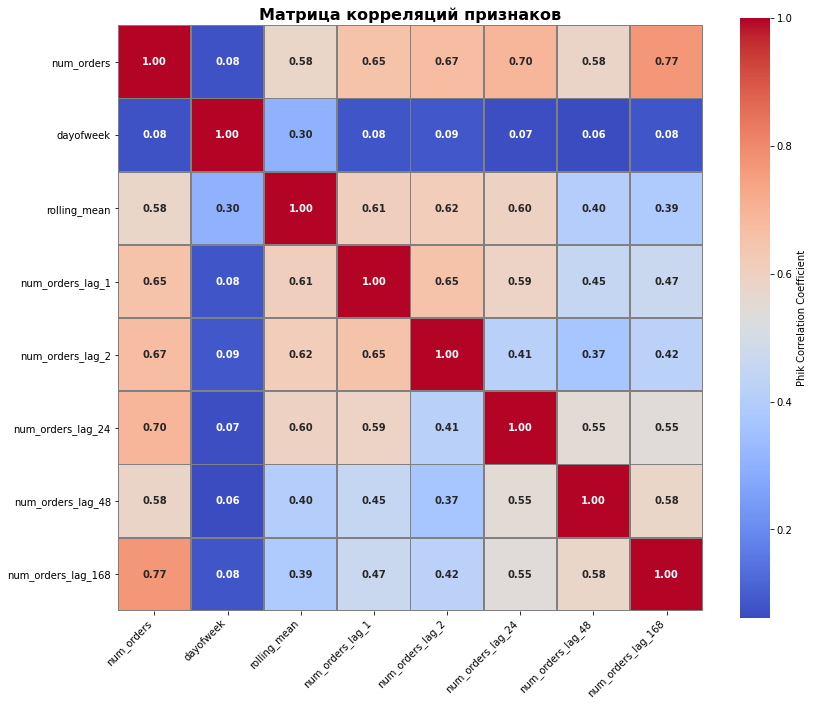

In [22]:
interval_columns = set(taxi_1h_new.columns) - {'dayofweek'}
corr_coefficients = taxi_1h_new.phik_matrix(interval_cols=interval_columns)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_coefficients,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10, "weight": "bold"},
    square=True,
    linewidths=0.8,
    linecolor='gray',
    cmap='coolwarm',
    cbar_kws={"label": "Phik Correlation Coefficient"},
    ax=ax
)
ax.set_title('Матрица корреляций признаков', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Обучение

In [23]:
RANDOM_STATE = 42

In [24]:
class MyDummyModel(BaseEstimator):
    def __init__(self, base_feature=None):
        self.base_feature = base_feature
        self.coef = 1
        
    def fit(self, X, y):
        if self.base_feature is None:
            self.base_feature = X.columns[0]
        self.is_fitted_ = True
        self.coef = y.mean() / X[self.base_feature].mean()
        return self
        
    def predict(self, X):
        return X[self.base_feature] * self.coef

In [25]:
train, test = train_test_split(taxi_1h_new, test_size=0.1, shuffle=False)
train = train.dropna().copy()

X_train, y_train = train.drop('num_orders', axis=1), train['num_orders']
X_test, y_test = test.drop('num_orders', axis=1), test['num_orders']


In [26]:
model_pipe = Pipeline(
    steps=[
        ('scaler', 'passthrough'), 
        ('selector', SelectKBest(f_regression)),
        ('model', LinearRegression())
    ]
)

In [27]:
%%time

model_pipe = Pipeline(
    steps=[
        ('scaler', 'passthrough'), 
        ('selector', SelectKBest(f_regression)),
        ('model', LinearRegression())
    ]
)

param_distributions = [
    {
        'selector': ['passthrough'],
        'model': [MyDummyModel()],
        'model__base_feature': ['num_orders_lag_1', 'num_orders_lag_24', 'num_orders_lag_168']
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [LinearRegression()],
        'model__fit_intercept': [True, False]
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [SVR()],
        'model__kernel': ['linear', 'poly'],
        'model__degree': randint(2, 4)
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [KNeighborsRegressor()],
        'model__n_neighbors': randint(1, 11),
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': randint(1, X_train.shape[1] + 1),
        'model__max_features': ['auto', 'sqrt', 'log2'],
        'model__min_samples_split': [5, 10, 20]
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [CatBoostRegressor(iterations=20, loss_function='RMSE', verbose=False, random_state=RANDOM_STATE)],
        'model__grow_policy': ['Depthwise', 'SymmetricTree']
    },
    {
        'scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
        'selector__k': randint(5, X_train.shape[1] + 1),
        'model': [LGBMRegressor(metric='rmse', verbose=0, random_state=RANDOM_STATE, force_col_wise=True)],
        'model__boosting_type': ['gbdt', 'dart'],
        'model__min_child_samples': randint(10, 80)
    }
]

model_search = RandomizedSearchCV(
    model_pipe,
    param_distributions,
    n_iter=50,
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    verbose=2
)

model_search.fit(X_train, y_train)
print(f'RMSE лучшей модели при кросс-валидации: {-model_search.best_score_:.2f} заказов')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [28]:
results = pd.DataFrame(model_search.cv_results_)[['param_model', 'params', 'rank_test_score', 'mean_test_score']]
results['param_model'] = results['param_model'].apply(lambda x: x.__class__.__name__)
results['mean_test_score'] = np.round(-results['mean_test_score'], 2)

results.sort_values(by='rank_test_score') \
       .pivot_table(index='param_model', aggfunc='first') \
       .sort_values(by='rank_test_score') \
       .reset_index() \
       .rename(columns={'param_model': 'Модель',
                        'mean_test_score': 'RMSE при кросс-валидации', 
                        'params': 'Параметры модели',
                        'rank_test_score': 'Ранг'}) \
       [['Модель', 'Ранг', 'RMSE при кросс-валидации', 'Параметры модели']]

,Модель,Ранг,RMSE при кросс-валидации,Параметры модели
0,SVR,1,22.42,"{'model': SVR(degree=2, kernel='linear'), 'mod..."
1,LinearRegression,5,22.47,"{'model': LinearRegression(), 'model__fit_inte..."
2,LGBMRegressor,11,23.29,"{'model': LGBMRegressor(force_col_wise=True, m..."
3,CatBoostRegressor,12,23.62,{'model': <catboost.core.CatBoostRegressor obj...
4,KNeighborsRegressor,19,23.86,"{'model': KNeighborsRegressor(), 'model__n_nei..."
5,DecisionTreeRegressor,35,25.47,{'model': DecisionTreeRegressor(random_state=4...
6,MyDummyModel,38,26.38,"{'model': MyDummyModel(), 'model__base_feature..."


Лучший результат при кросс-валидации RMSE=22.42 показал метод опорных векторов SVR с линейным ядром.

## Тестирование

In [29]:
predict = model_search.predict(X_test)
f'RMSE на тестe: {mean_squared_error(y_test, predict, squared=False):.2f} заказов'

'RMSE на тестe: 35.20 заказов'

Достигнут требуемый результат (RMSE не больше 48 на тесте)

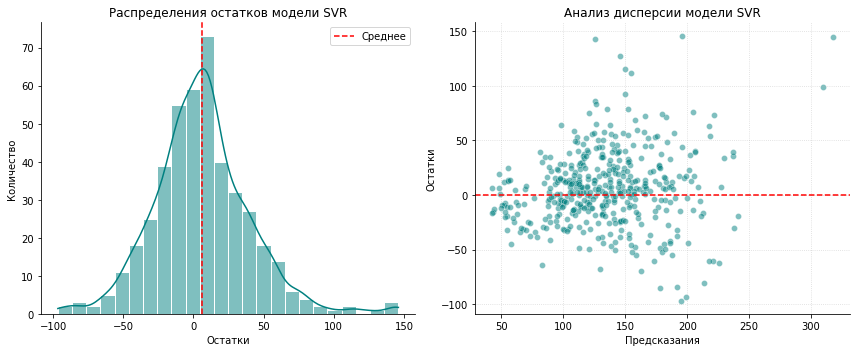

In [30]:
residuals = y_test - predict

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.3)

sns.histplot(x=residuals, ax=ax1, kde=True, kde_kws={'bw_method': 0.2}, edgecolor='white', color='teal')
ax1.axvline(np.mean(residuals), color='red', linestyle='--', label='Среднее')
ax1.set_title('Распределения остатков модели SVR')
ax1.set_xlabel('Остатки')
ax1.set_ylabel('Количество')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

sns.scatterplot(x=predict, y=residuals, ax=ax2, alpha=0.5, color='teal')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Анализ дисперсии модели SVR')
ax2.set_xlabel('Предсказания')
ax2.set_ylabel('Остатки')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.5, linestyle=':')

plt.tight_layout()
plt.show()

Распределение достаточно близко к нормальному

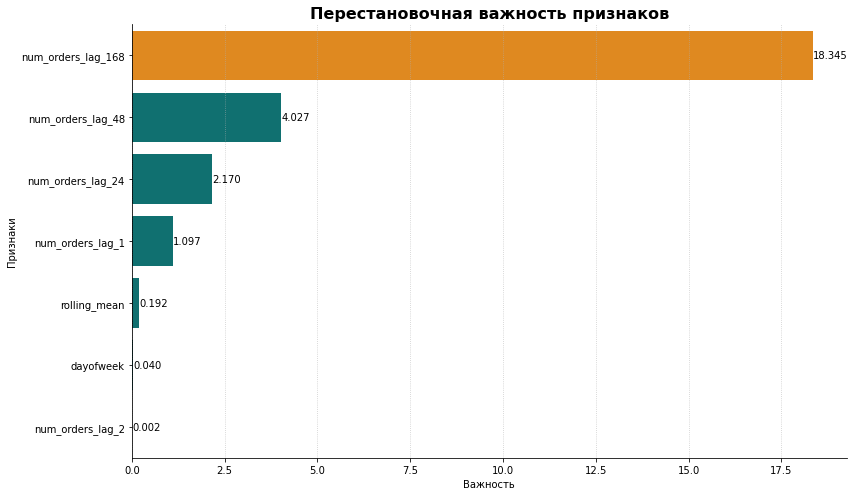

In [31]:
permutation = permutation_importance(
    model_search, X_test, y_test,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE
)

feature_importances = pd.DataFrame({
    'feature': X_test.columns,
    'importance': permutation['importances_mean']
})

fi_filtered = feature_importances.sort_values(by='importance', ascending=False)
colors = ['teal'] * len(fi_filtered)
if len(colors) > 0:
    colors[0] = 'darkorange'

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    x='importance',
    y='feature',
    data=fi_filtered,
    palette=colors,
    ax=ax
)
for i, (imp, feat) in enumerate(zip(fi_filtered['importance'], fi_filtered['feature'])):
    ax.text(imp + 0.001, i, f'{imp:.3f}', va='center')
ax.set_title('Перестановочная важность признаков', fontsize=16, fontweight='bold')
ax.set_xlabel('Важность')
ax.set_ylabel('Признаки')
ax.grid(axis='x', linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Самое большое влияние оказывает кол-во заказов с багами в неделю.

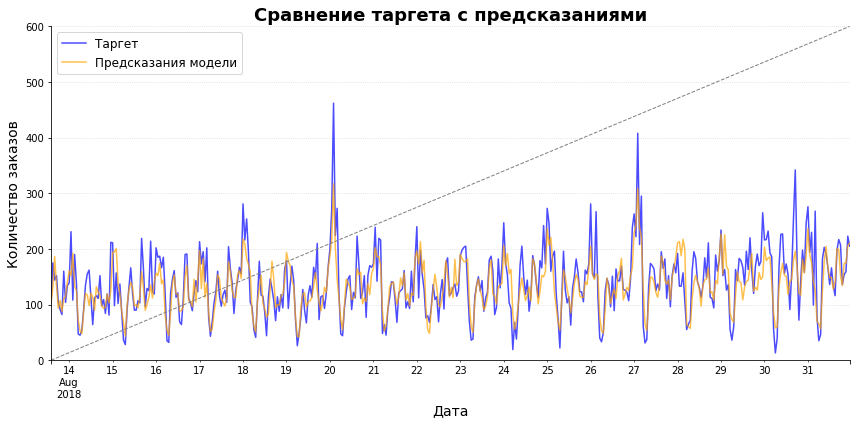

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

pd.DataFrame({'target': y_test, 'predict': predict}, index=y_test.index).plot(
    ax=ax, color=['blue', 'orange'], alpha=0.7
)

ax.set_title('Сравнение таргета с предсказаниями', fontsize=18, fontweight='bold')
ax.set_xlabel('Дата', fontsize=14)
ax.set_ylabel('Количество заказов', fontsize=14)
ax.set_ylim(0, 600)
ax.legend(['Таргет', 'Предсказания модели'], fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.5, linestyle=':')

ax.plot(ax.get_xlim(), ax.get_ylim(), color='grey', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

В процессе работы были обработаны и проанализированы исторические данные по заказам такси в аэропортах, охватывающие период с 1 марта по 31 августа 2018 года. Данные оказались чистыми: пропуски, дубликаты и выбросы выявлены не были. Анализ временного ряда позволил зафиксировать выраженные суточные и недельные колебания спроса, а также устойчивый рост количества заказов весной и летом.

Перед построением предиктивных моделей были сформированы дополнительные признаки: календарные, лаговые (отстающие значения) и скользящее среднее. С помощью различных моделей машинного обучения было спрогнозировано количество заказов такси на ближайший час. Оценив качество предсказаний по метрике RMSE, оптимальным решением оказалась модель опорных векторов (SVR) с линейным ядром: на тестовых данных она показала RMSE = 35.2, что соответствует заданному критерию качества. Модель зарекомендовала себя как наиболее подходящая для решения задачи оперативного прогнозирования почасовых заказов такси в аэропортах. Такой выбор поможет логистическим службам эффективно регулировать число доступных водителей и обеспечить высокий уровень обслуживания.